### GFS sampling paper plot

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import graphical_sampling as gs
from graphical_sampling.index import Moran

Sample: [0 2 3 7]
Moran(sample): -0.4431345059425176


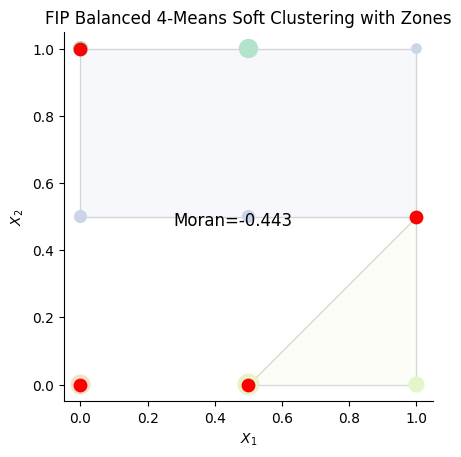

In [ ]:
# --- Population ---
coords_data = np.array([
    (1,1),(1,2),(1,3),
    (2,1),(2,2),(2,3),
    (3,1),(3,2),(3,3)
])

inclusions_data = np.array([0.7, 0.3, 0.4, 0.8, 0.3, 0.65, 0.45, 0.2, 0.2])
n = int(inclusions_data.sum())

pop = gs.Population(coords_data, inclusions_data, n=n, variable=inclusions_data)

# --- Clustering ---
fbn = gs.clustering.FIPBalancedNMeans(
    n=n,
    centroid_grid_x=1,
    r_sample_per_cluster=1,
    init_clust_method='expanded',
    split_size=.001
)

fbn.fit(pop)
fbn.fit_zones(num_zones=(1,1), mode='sweep_yx')

# --- Order & Design ---
order = gs.Order.from_clusters(
    pop,
    fbn.clusters,
    zone_strategy='lexico_yx',
    point_strategy='lexico_yx',
    num_splits=1,
    topological=True
)

design = gs.Design.from_order(pop, order)

# =========================================================
# 🔴 STEP 1: draw ONE sample from the design
# =========================================================
sample = design.sample(1)[0]   # shape (n,)
print("Sample:", sample)

# =========================================================
# 🔴 STEP 2: Moran for THIS sample (not expected value)
# =========================================================
moran_index = Moran(pop)
moran_val = moran_index.score(np.array([sample]))[0]

print("Moran(sample):", moran_val)

# =========================================================
# 🔴 STEP 3: Plot
# =========================================================
fig, ax = plt.subplots()

# background clusters
fbn.plot(mode='soft', ax=ax)

coords = pop.coords

# highlight selected units
ax.scatter(coords[sample, 0], coords[sample, 1],
           color="red", s=80, zorder=10)

# label
x, y = coords[sample].mean(axis=0)
ax.text(x-0.1, y+0.1, f"Moran={moran_val:.3f}", fontsize=12)

plt.show()